Iniciando generacion de graficas del TFM...

2/7  Figura 2  — DBSCAN: k-Distance plot...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


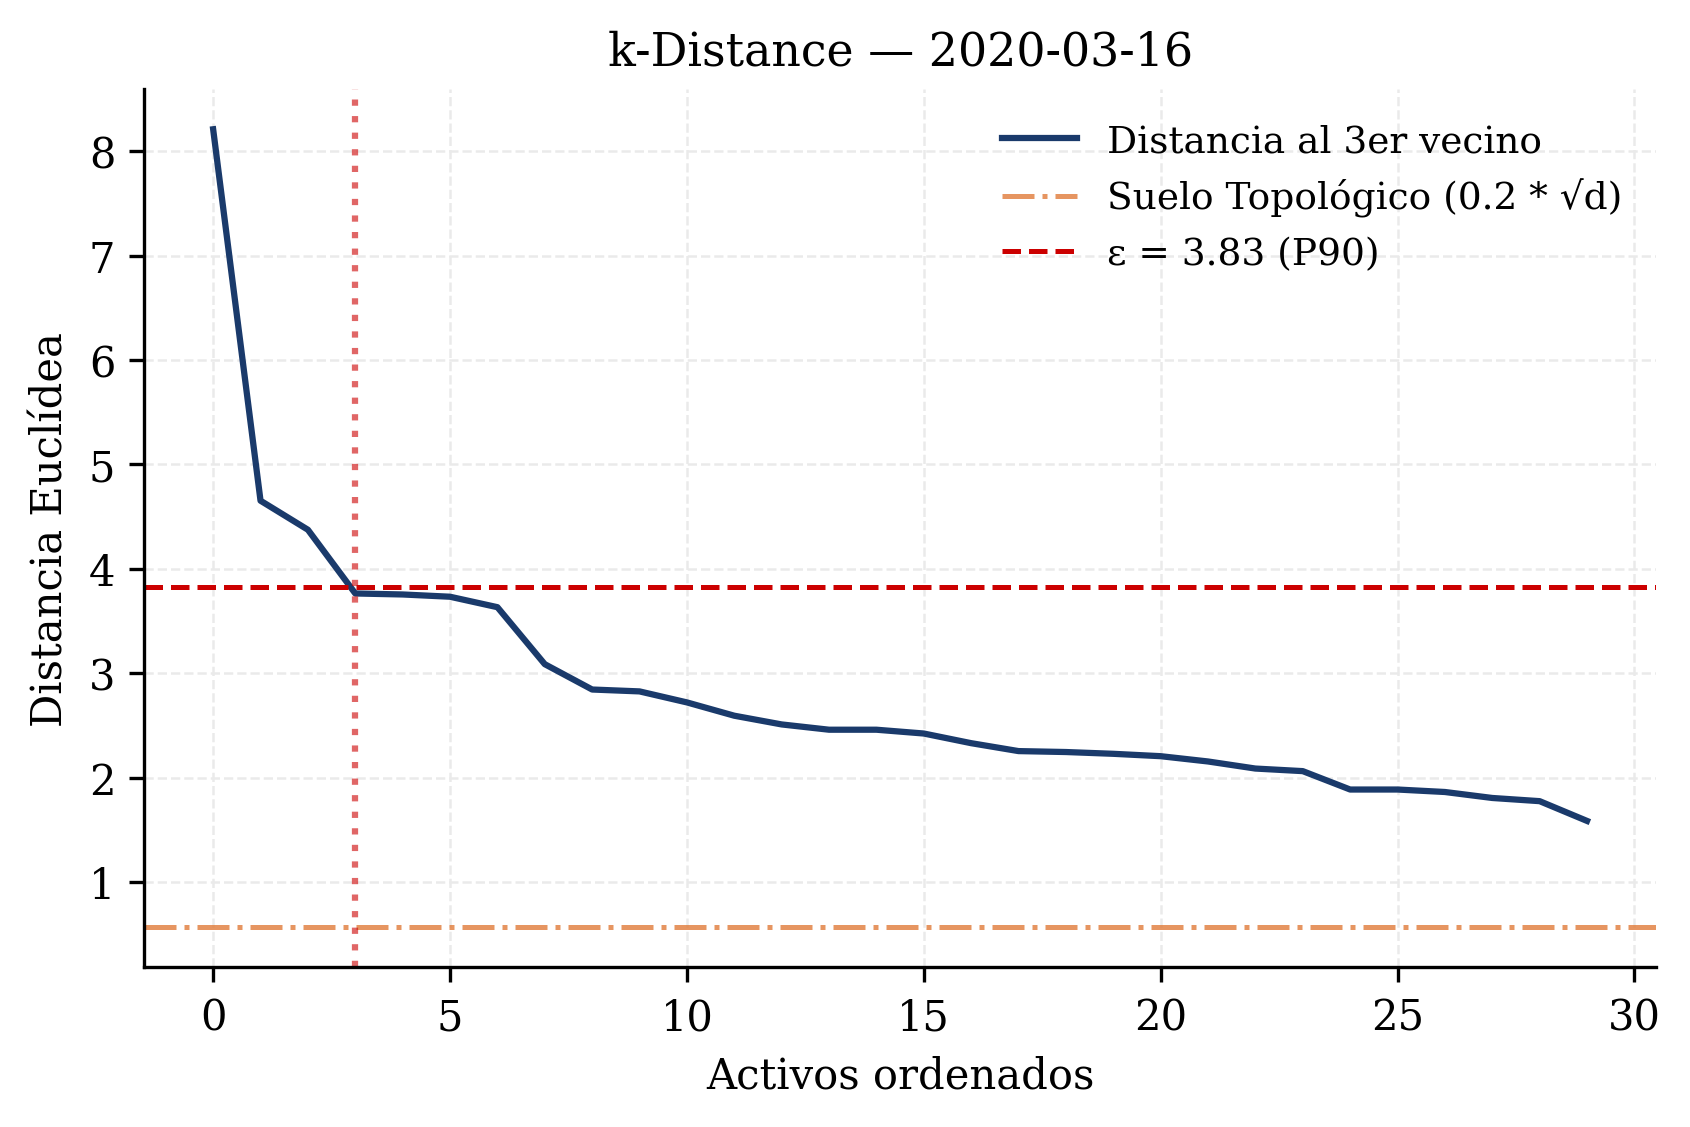

3/7  Figura 3  — DBSCAN: Evolución epsilon...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


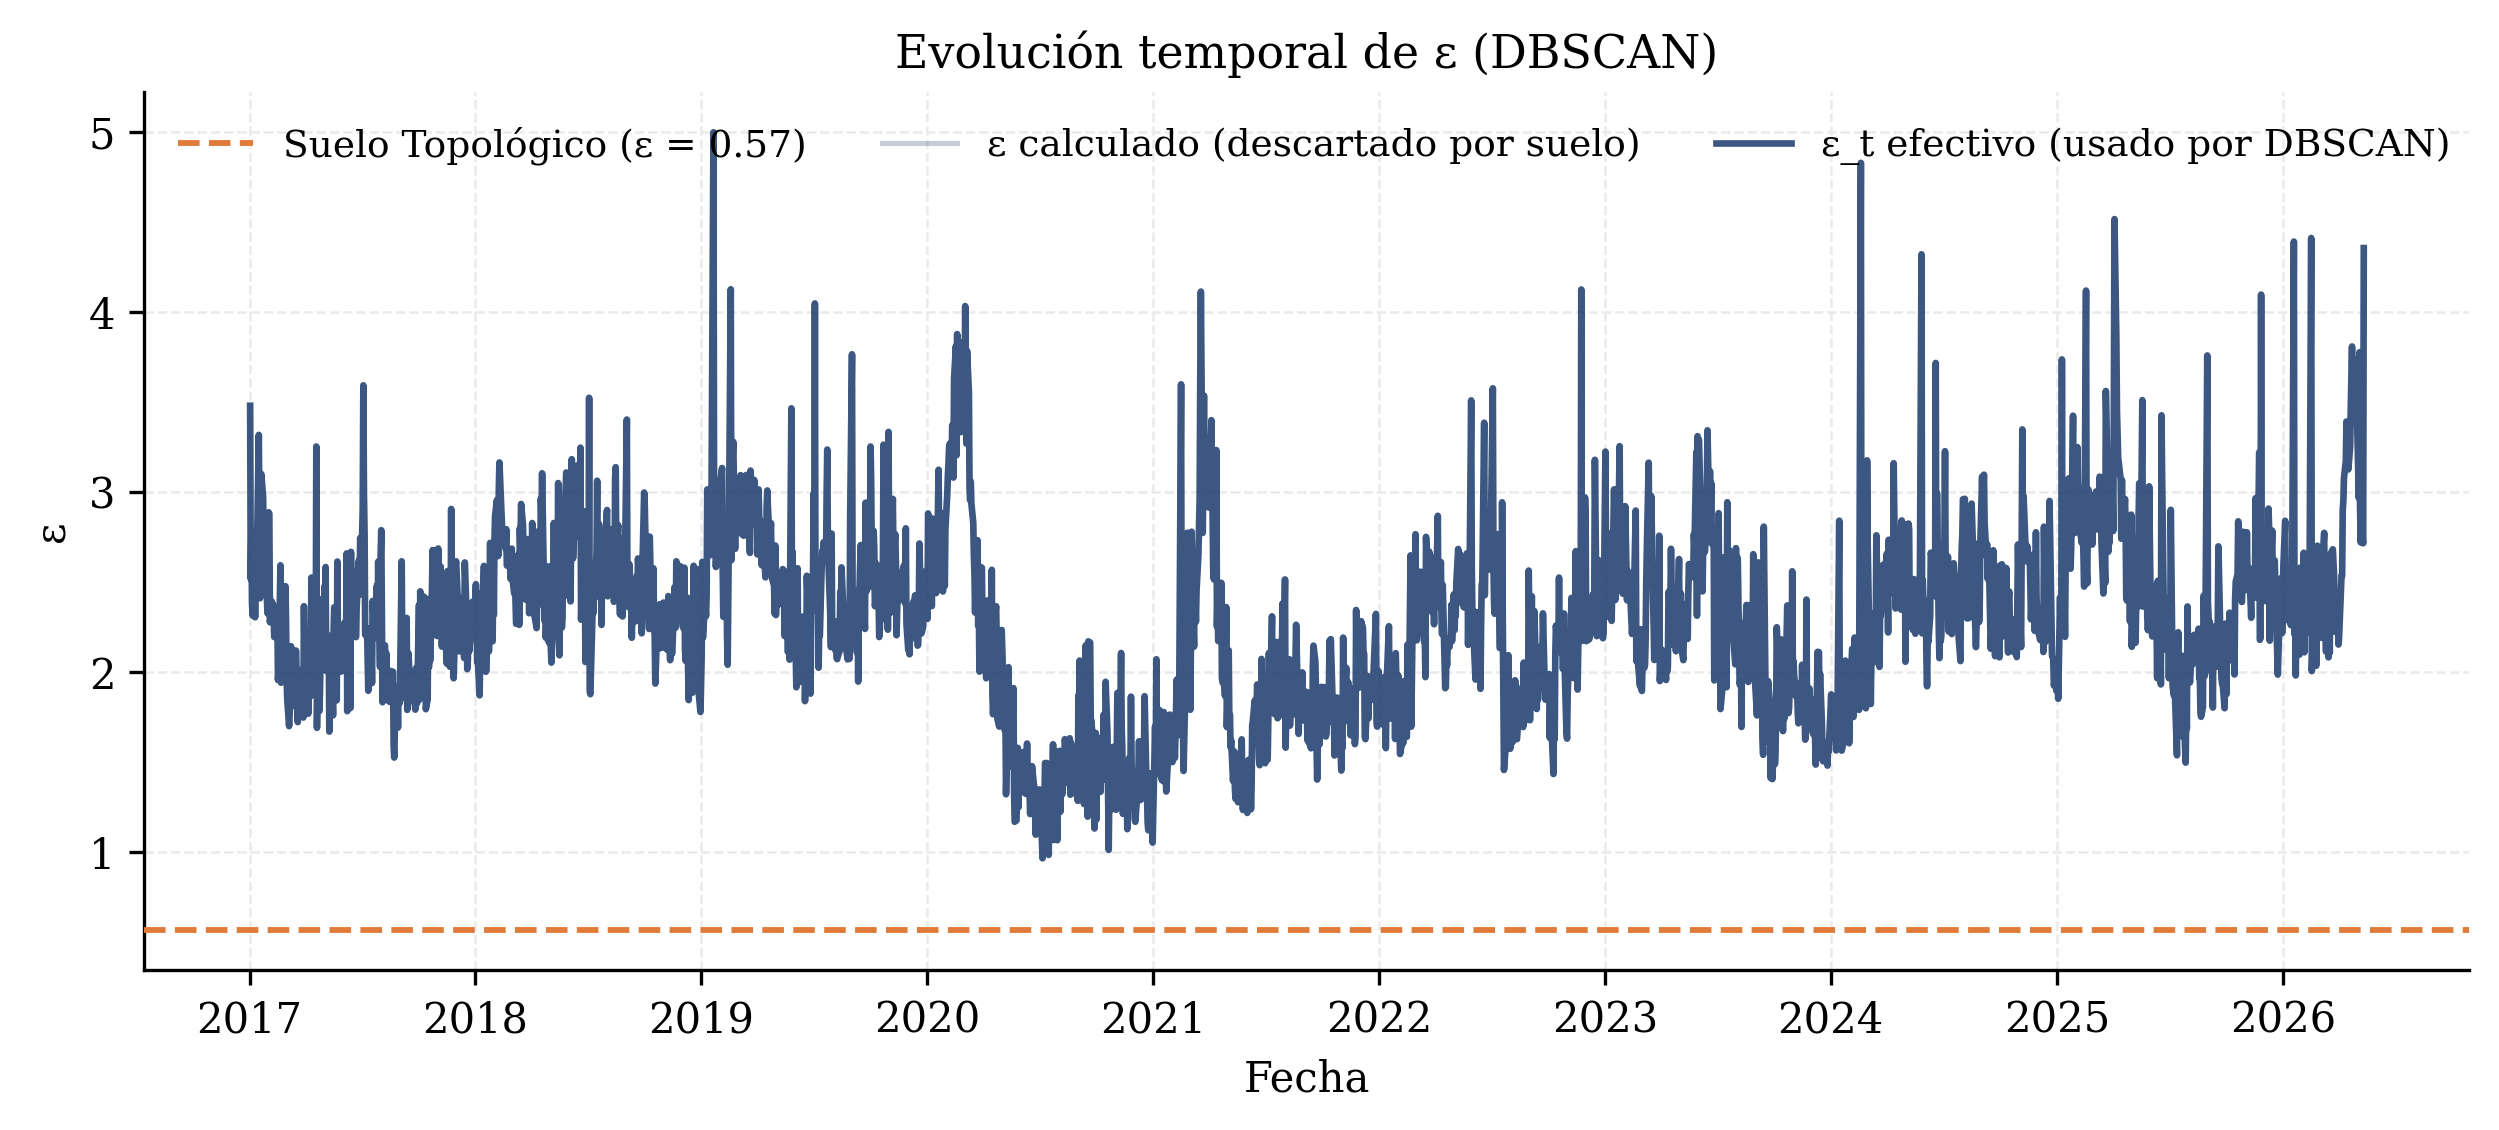

4/7  Figura 4  — Sismógrafo de anomalías...


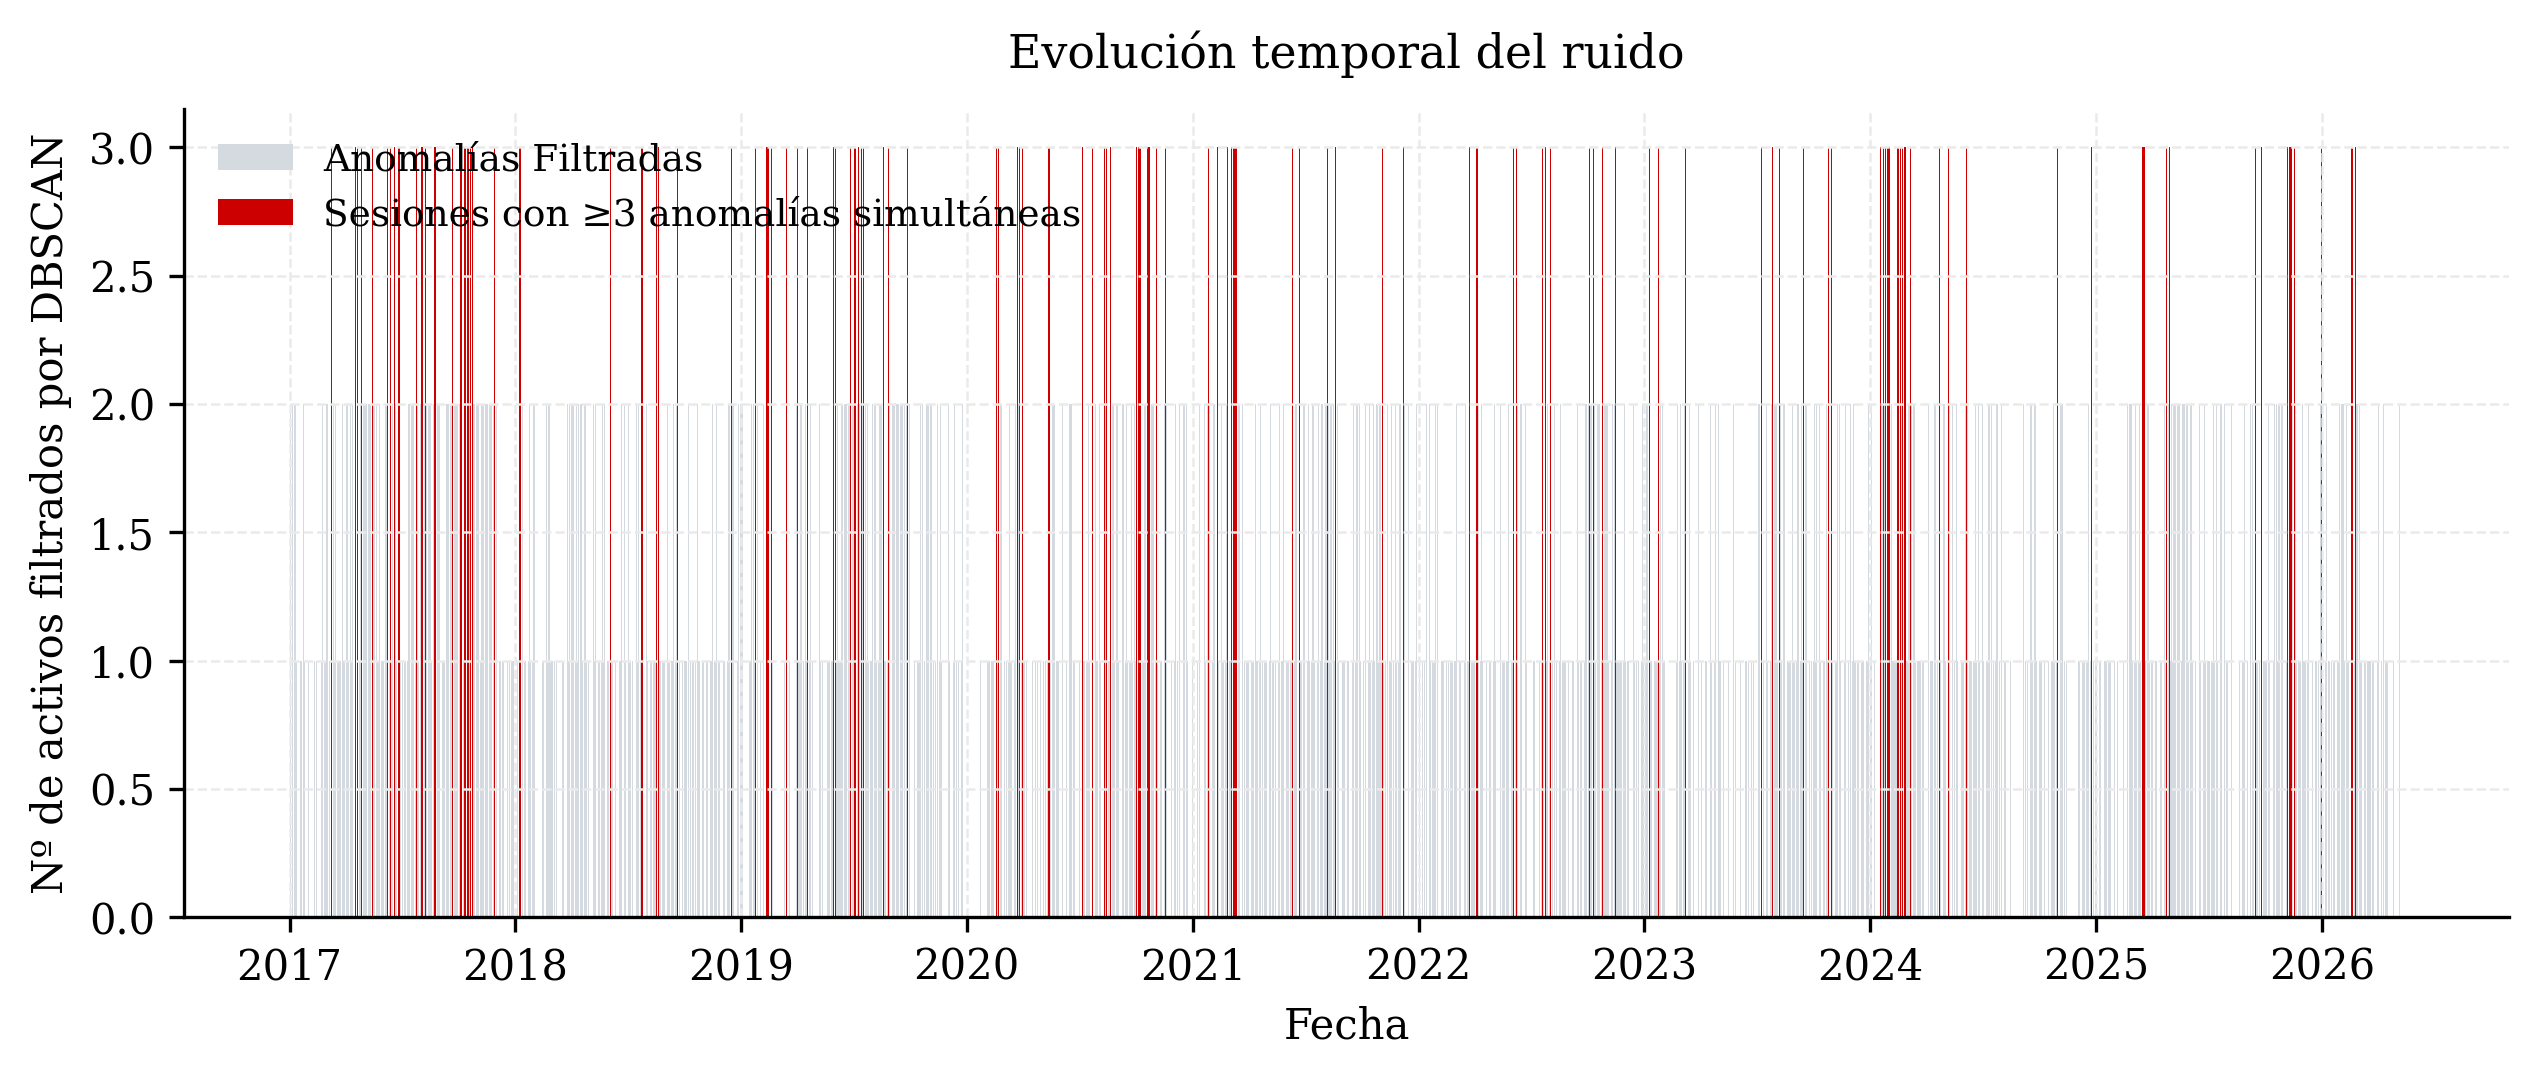

5/7  Figura 5  — PCA Scatter (COVID Crash)...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


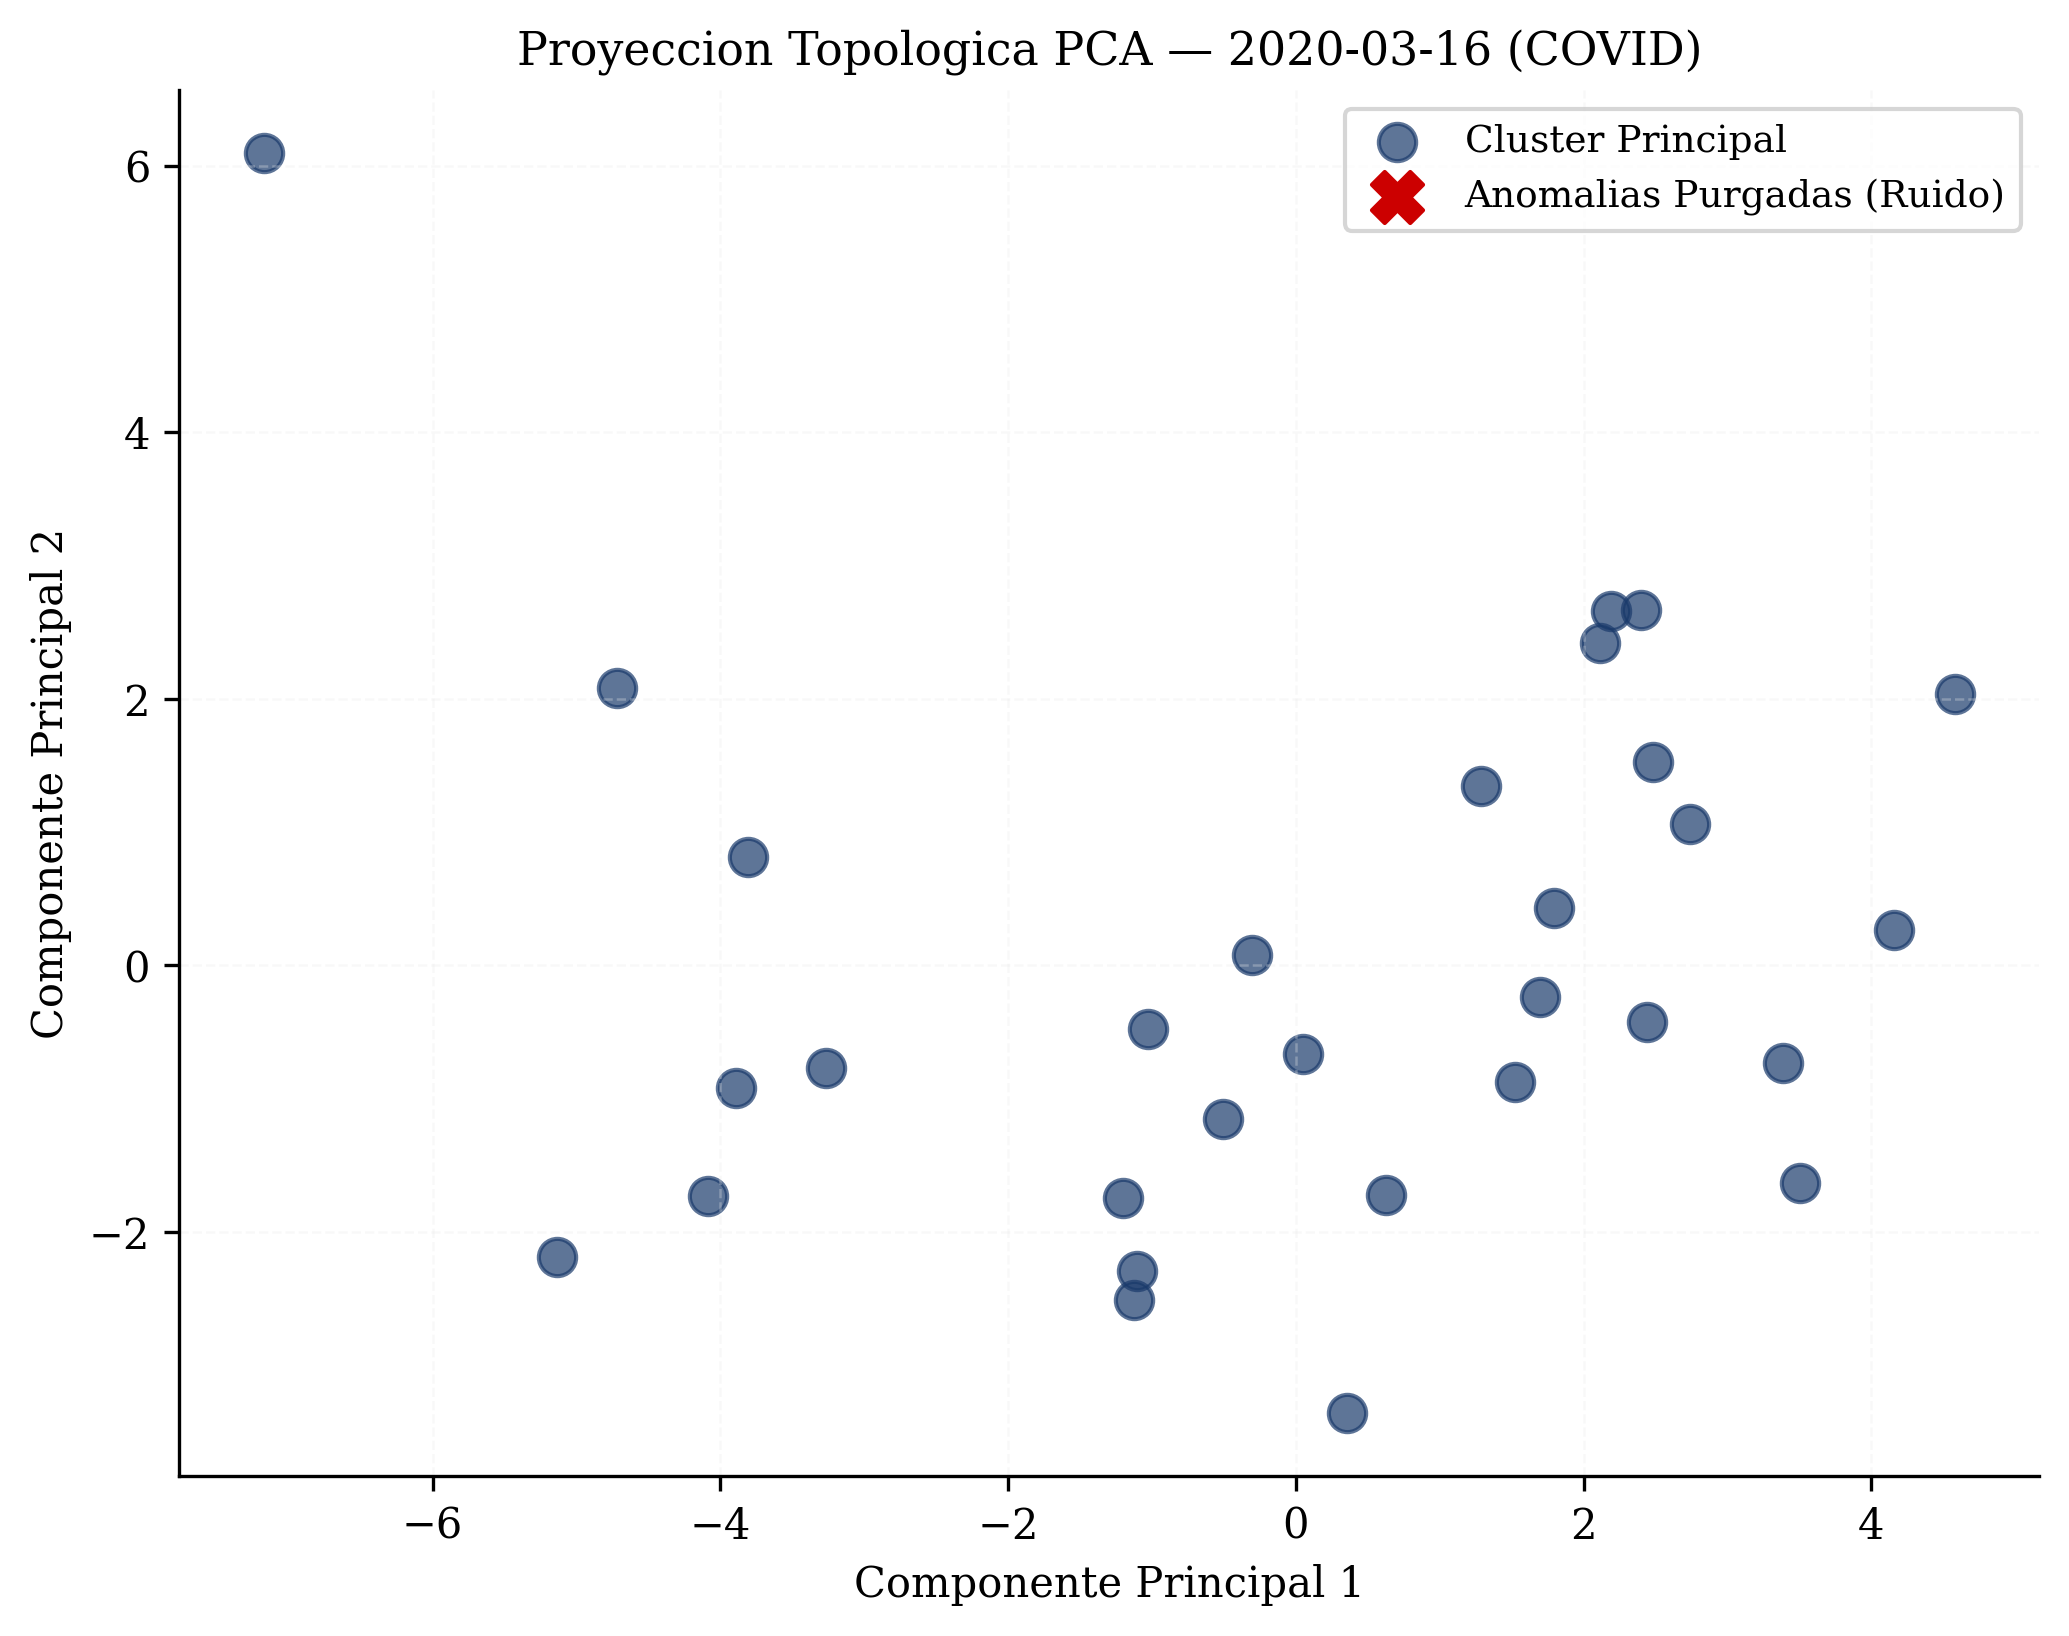

6/7  Figura 6  — Z-Score: series temporales...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


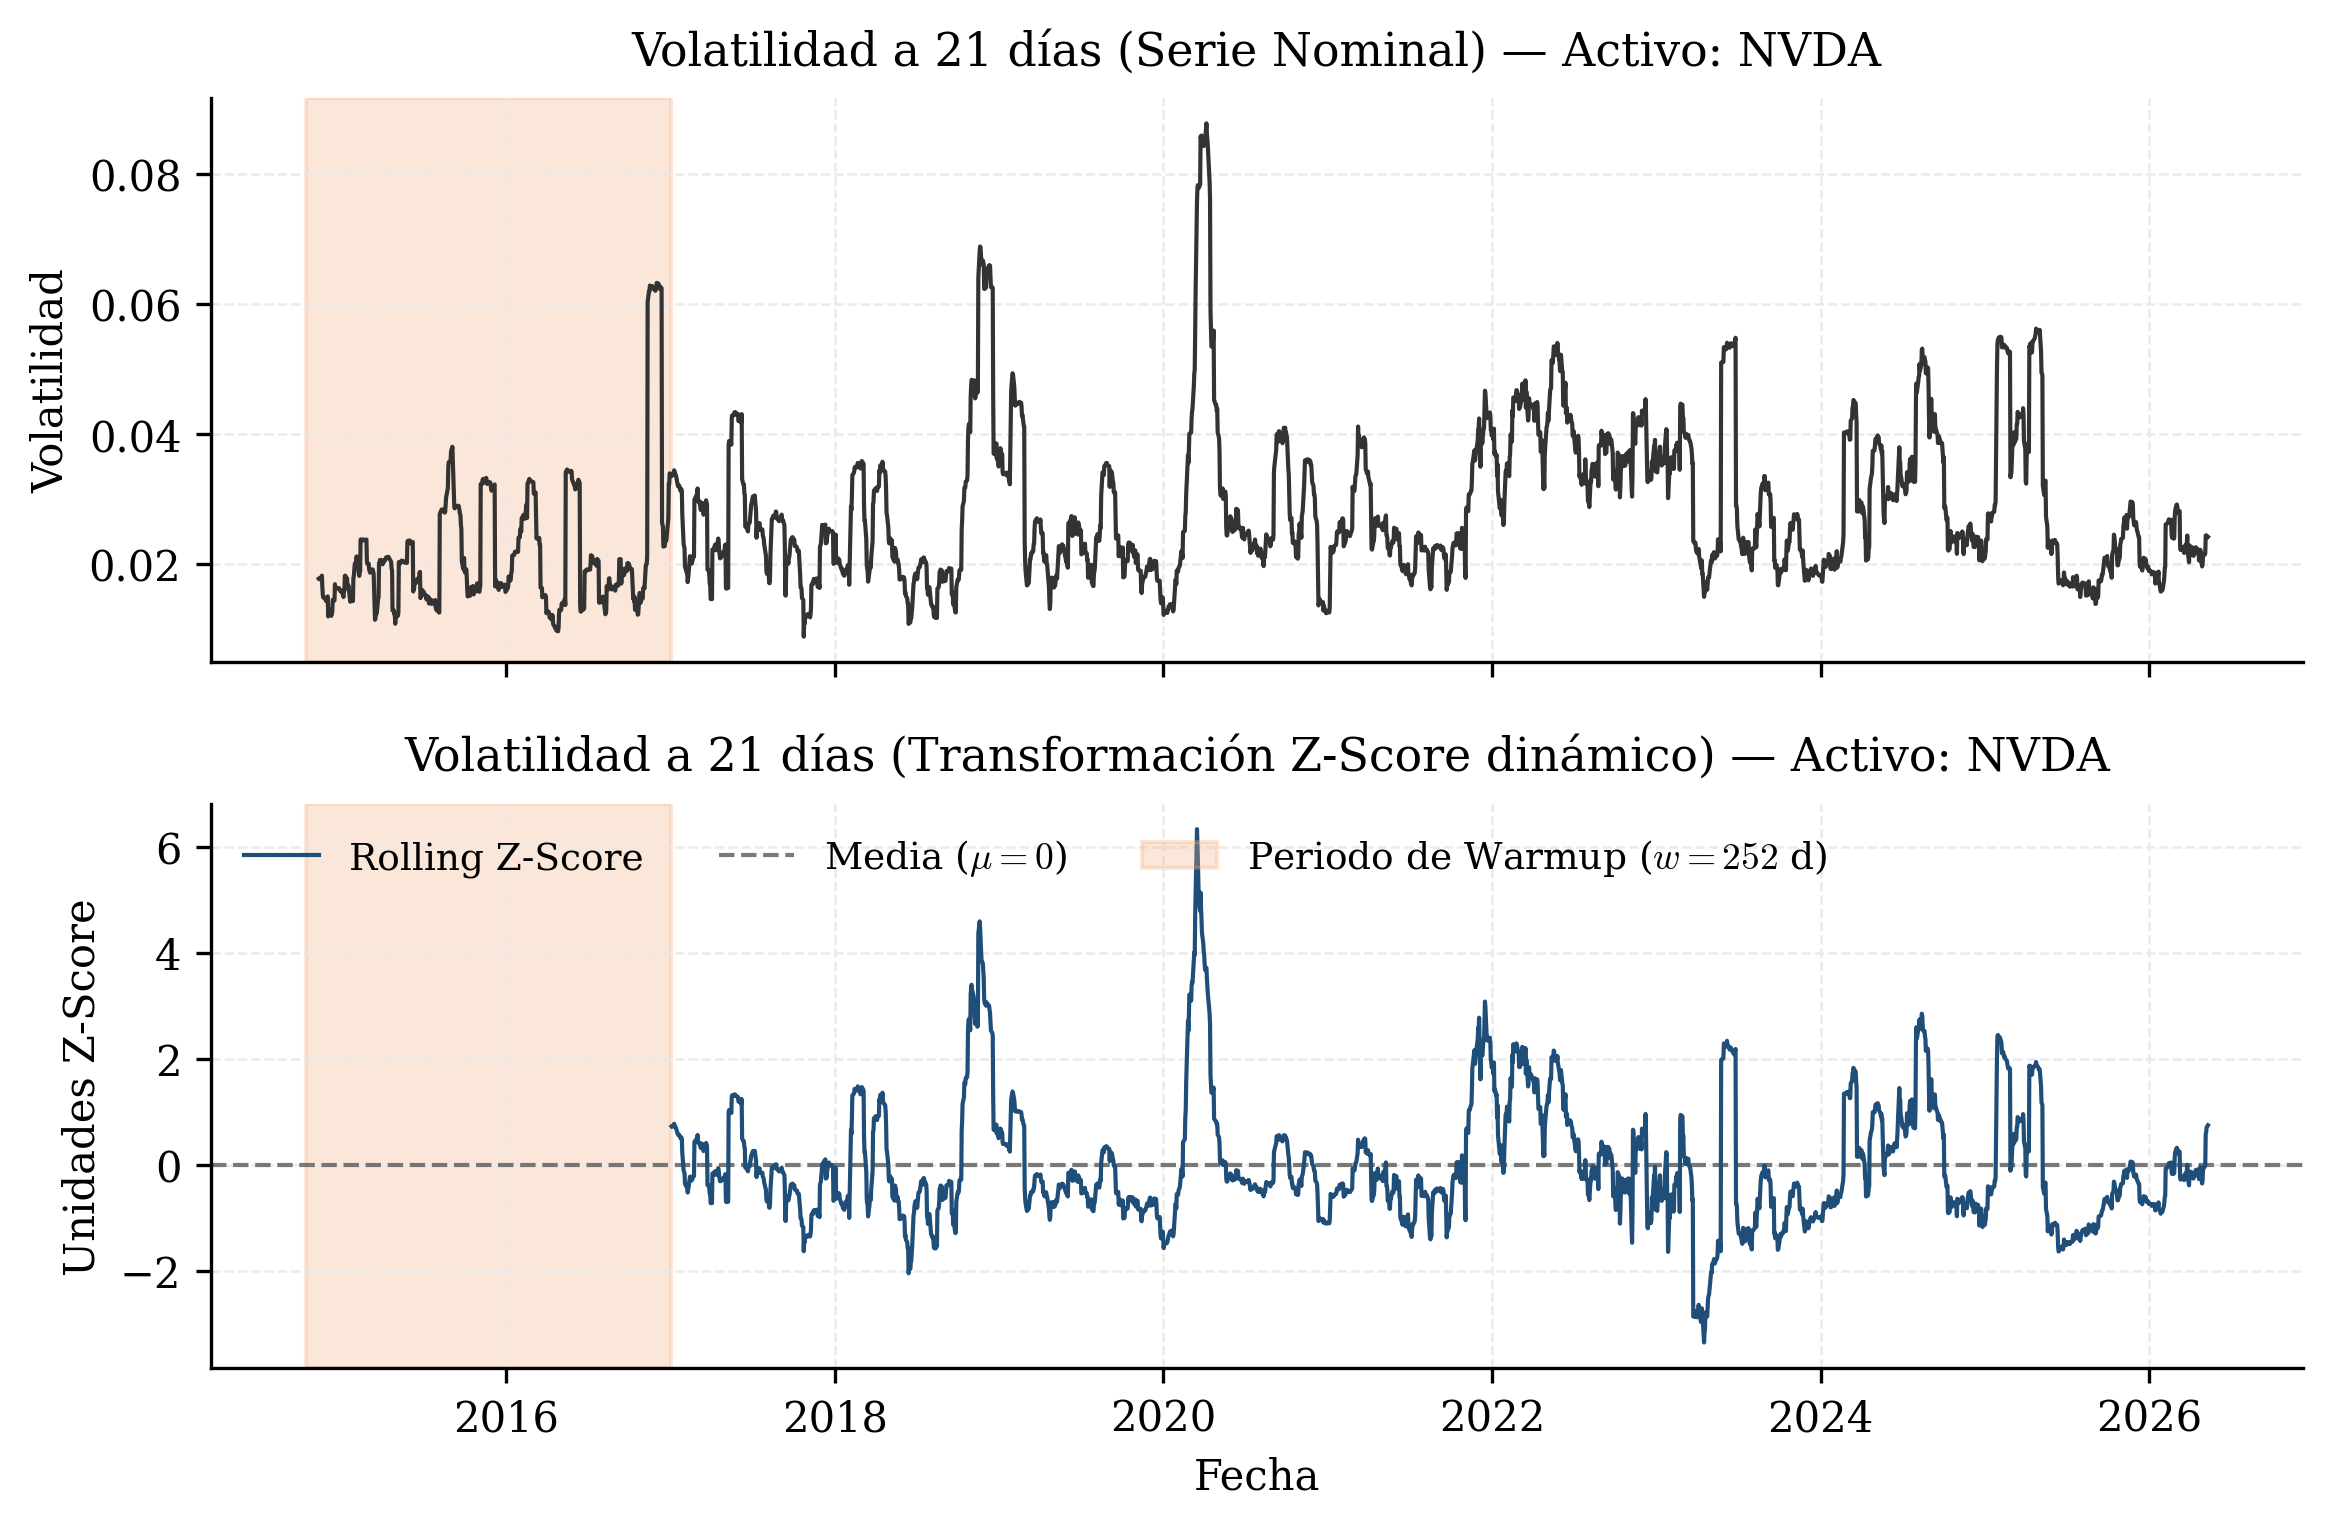

7/7  Figura 7  — Z-Score: distribución KDE...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


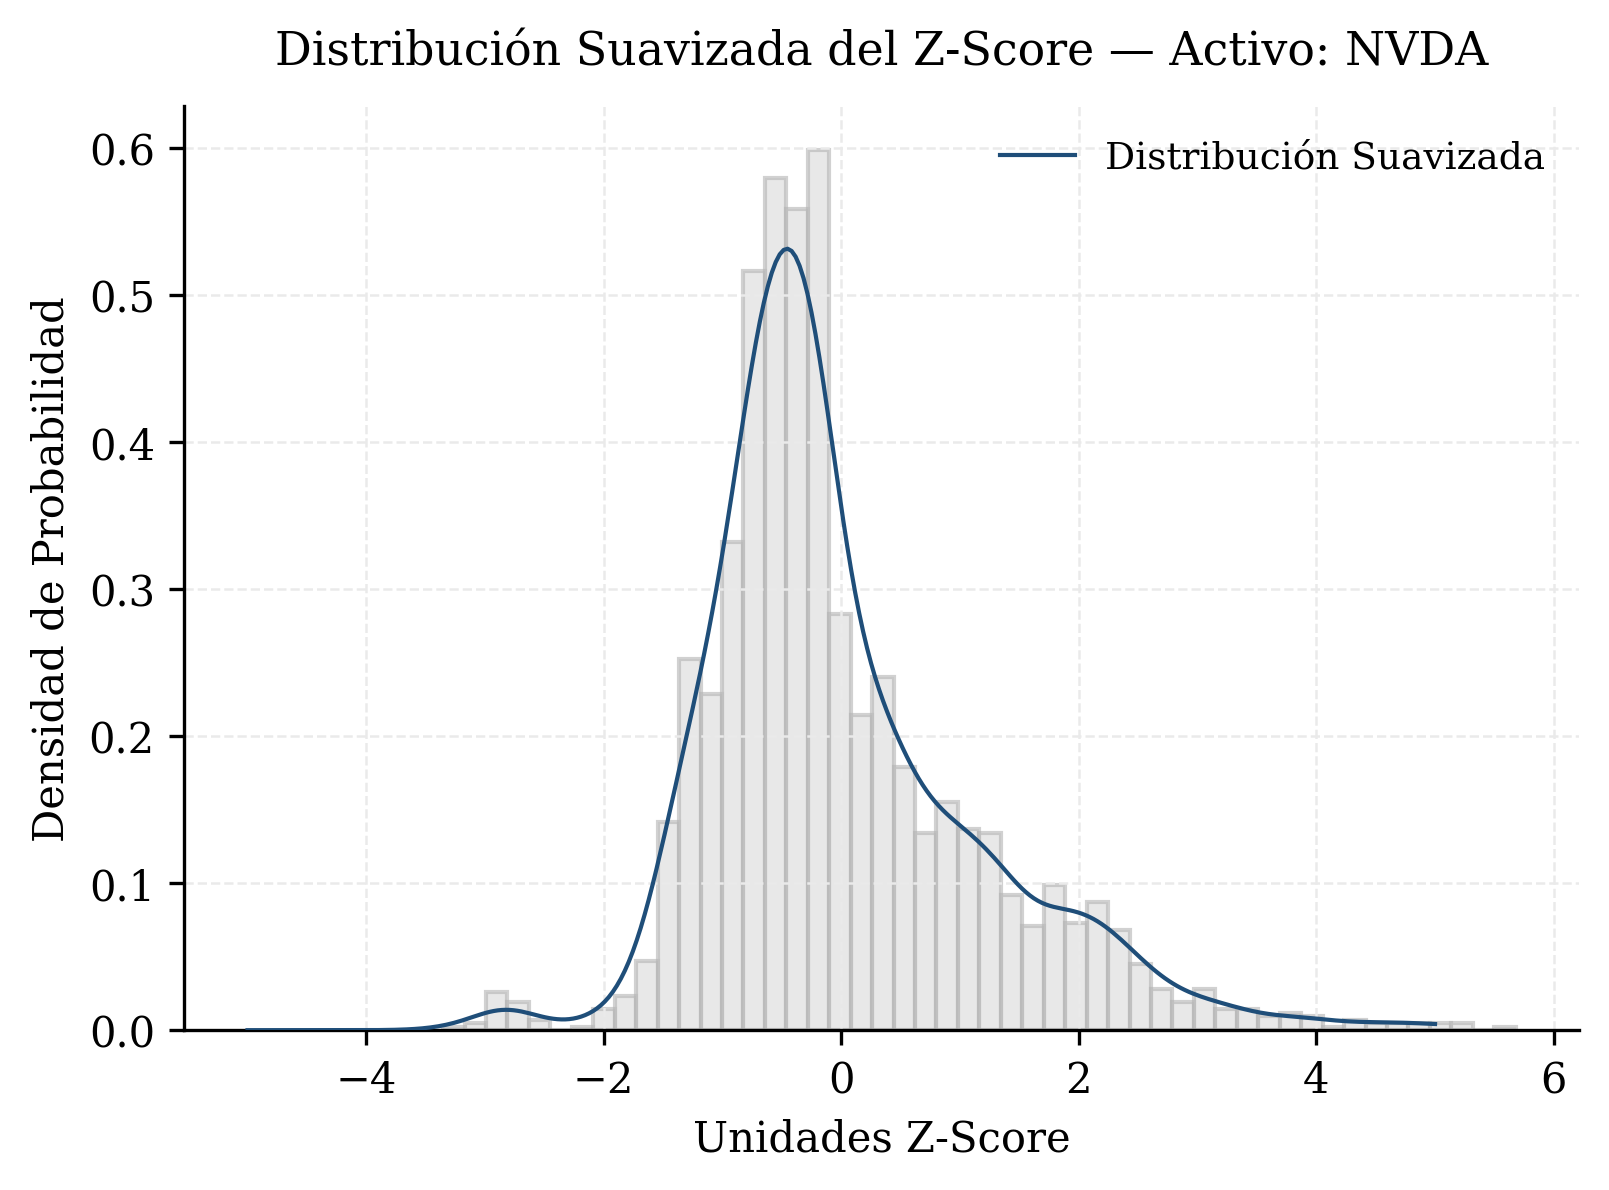

 Todas las graficas guardadas en la carpeta 'media/'.


In [17]:
# =============================================================================
# TFM — GENERACIÓN DE FIGURAS 
# =============================================================================

# ===========================================================================
# BLOQUE 0: IMPORTACIONES
# ===========================================================================

# — Librería estándar —
import os

# — Terceros: cómputo y datos —
import numpy as np
import pandas as pd
import ta

# — Terceros: visualización —
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# — Terceros: machine learning —
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# ===========================================================================
# BLOQUE 1: CONFIGURACIÓN GLOBAL
# ===========================================================================

OUTPUT_DIR = "../media"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paleta corporativa
C_BLUE   = "#1a3a6b"
C_GRAY   = "#6e7f8d"
C_LGRAY  = "#d4dae0"
C_RED    = "#cc0000"
C_ORANGE = "#e07b39"

# Estilo base — aplicado a todas las figuras salvo sobreescritura explícita
RCPARAMS_BASE = {
    "text.usetex":        False,
    "mathtext.fontset":   "cm",
    "font.family":        "serif",
    "axes.labelsize":     10,
    "axes.titlesize":     11,
    "legend.fontsize":    9,
    "figure.dpi":         300,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#eaeaea",
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
}

mpl.rcParams.update(RCPARAMS_BASE)

# Features estándar usadas por DBSCAN en todas las figuras que las necesiten
DBSCAN_FEATURES = [
    "ALR12M_SKIP_Z", "ALR6M_SKIP_Z", "ALR1M_Z",
    "MACD_Hist_Z",   "RSI_14_Z",     "Volatilidad_252d_Z",
    "ATR_14_Z",      "Vol_Relativo_Z",
]


# ===========================================================================
# BLOQUE 2: UTILIDADES INTERNAS
# ===========================================================================

def _save(fig: plt.Figure, stem: str) -> None:
    """Guarda la figura en PNG y EPS dentro de OUTPUT_DIR."""
    fig.savefig(os.path.join(OUTPUT_DIR, f"{stem}.png"), bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"{stem}.eps"), format="eps", bbox_inches="tight")


def _resolve_fecha(df: pd.DataFrame, fecha_str: str) -> pd.Timestamp:
    """Devuelve la fecha exacta pedida o la siguiente disponible si no existe."""
    fecha = pd.to_datetime(fecha_str)
    if fecha not in df["Fecha"].values:
        fecha = df["Fecha"][df["Fecha"] >= fecha].min()
    return fecha


def _ensure_raw_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula los indicadores técnicos brutos si aún no están en el DataFrame."""
    df = df.copy()
    grp = df.groupby("Ticker")

    if "RSI_14" not in df.columns:
        df["RSI_14"] = grp["Precio_Adj"].transform(
            lambda s: ta.momentum.rsi(s, window=14)
        )
    if "DailyLogReturn" not in df.columns:
        df["DailyLogReturn"] = grp["Precio_Adj"].transform(
            lambda s: np.log(s / s.shift(1))
        )
    if "Volatilidad_21d" not in df.columns:
        df["Volatilidad_21d"] = grp["DailyLogReturn"].transform(
            lambda s: s.rolling(21).std()
        )
    if "MACD_Hist" not in df.columns:
        df["MACD_Hist"] = grp["Precio_Adj"].transform(
            lambda s: ta.trend.macd_diff(s, 26, 12, 9)
        )
    return df



# ===========================================================================
# BLOQUE 4: FIGURA 2 — DBSCAN: K-DISTANCE PLOT
# ===========================================================================

def fig2_kdistance(df_dbscan: pd.DataFrame, fecha_str: str = "2020-03-16") -> None:
    """
    Figura 4.4a: K-Distance plot para selección del hiperparámetro ε.
    Guarda: k_distance_plot.{png,eps}
    """
    df_dbscan = df_dbscan.copy()
    df_dbscan["Fecha"] = pd.to_datetime(df_dbscan["Fecha"])
    fecha_target = _resolve_fecha(df_dbscan, fecha_str)

    corte = df_dbscan[df_dbscan["Fecha"] == fecha_target].copy()
    feats = [f for f in DBSCAN_FEATURES if f in corte.columns]
    X = corte[feats].dropna().values

    if len(X) < 4:
        print(f"[fig2_kdistance] Datos insuficientes para {fecha_target.date()}.")
        return
        
    # --- ACTUALIZACIÓN DE LÓGICA MATEMÁTICA ---
    d = X.shape[1] # Extracción dinámica del número de dimensiones (d=5 según actualización)
    suelo_eps = 0.2 * np.sqrt(d)

    nbrs = NearestNeighbors(n_neighbors=4, metric="euclidean").fit(X)
    dists, _ = nbrs.kneighbors(X)
    k_dists = np.sort(dists[:, -1])[::-1]

    # Nueva lógica para eps final elegido (respetando el max)
    eps_val = max(suelo_eps, float(np.percentile(k_dists, 90)))
    idx_eps = np.searchsorted(-k_dists, -eps_val)

    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(k_dists, color=C_BLUE, linewidth=1.5, label="Distancia al 3er vecino")
    
    # Línea del suelo topológico requerida
    ax.axhline(suelo_eps, color=C_ORANGE, linestyle="-.", linewidth=1.2, alpha=0.8,
               label=r'Suelo Topológico (0.2 * √d)')
               
    # Línea del Épsilon escogido
    ax.axhline(eps_val, color=C_RED, linestyle="--", linewidth=1.2,
               label=f"ε = {eps_val:.2f} (P90)")
    
    ax.axvline(idx_eps, color=C_RED, linestyle=":", alpha=0.6)
    
    ax.set_title(f"k-Distance — {fecha_target.date()}")
    ax.set_xlabel("Activos ordenados")
    ax.set_ylabel("Distancia Euclídea")
    ax.legend(frameon=False)

    _save(fig, "k_distance_plot")
    plt.show()


# ===========================================================================
# BLOQUE 5: FIGURA 3 — DBSCAN: EVOLUCIÓN TEMPORAL DE EPSILON
# ===========================================================================

def fig3_epsilon_evolution(df_dbscan: pd.DataFrame) -> None:
    """
    Figura 4.4b: Evolución temporal del parámetro ε usado por DBSCAN.
    Guarda: epsilon_evolution.{png,eps}
    """
    df_dbscan = df_dbscan.copy()
    df_dbscan["Fecha"] = pd.to_datetime(df_dbscan["Fecha"])
    
    # Extraemos d basándonos en las features presentes en el dataset
    feats = [f for f in DBSCAN_FEATURES if f in df_dbscan.columns]
    d = len(feats) if len(feats) > 0 else 5
    FLOOR = 0.2 * np.sqrt(d)

    eps_ts     = df_dbscan.groupby("Fecha")["DBSCAN_eps"].first().sort_index()
    eps_raw_ts = df_dbscan.groupby("Fecha")["DBSCAN_eps_raw"].first().sort_index()

    fig, ax = plt.subplots(figsize=(10, 3.8))

    # Floor mínimo (Actualizado con la nueva lógica matemática)
    ax.axhline(FLOOR, color=C_ORANGE, linestyle="--", linewidth=1.4,
               label=f"Suelo Topológico (ε = {FLOOR:.2f})", zorder=4)

    # ε calculado descartado (por debajo del floor)
    eps_raw_descartado = eps_raw_ts.where(eps_raw_ts < FLOOR)
    ax.plot(eps_raw_descartado.index, eps_raw_descartado.values,
            color=C_BLUE, linewidth=1.2, alpha=0.25, linestyle="-", zorder=2,
            label="ε calculado (descartado por suelo)")

    # Relleno entre valor descartado y floor
    ax.fill_between(
        eps_raw_ts.index, eps_raw_ts.values, FLOOR,
        where=(eps_raw_ts.values < FLOOR),
        color=C_BLUE, alpha=0.08, interpolate=True, zorder=1,
    )

    # ε efectivo (siempre ≥ FLOOR)
    ax.plot(eps_ts.index, eps_ts.values,
            color=C_BLUE, linewidth=1.6, alpha=0.85, zorder=3,
            label="ε_t efectivo (usado por DBSCAN)")

    ax.set_title("Evolución temporal de ε (DBSCAN)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("ε")
    ax.legend(loc="upper left", frameon=False, ncol=3)

    _save(fig, "epsilon_evolution")
    plt.show()


# ===========================================================================
# BLOQUE 6: FIGURA 4 — SISMÓGRAFO DE ANOMALÍAS
# ===========================================================================

def fig4_sismografo_anomalias(df_dbscan: pd.DataFrame) -> None:
    """
    Figura 4.5: Evolución temporal del ruido (activos clasificados como anomalía).
    Guarda: anomaly_timeline.{png,eps}
    """
    df_dbscan = df_dbscan.copy()
    df_dbscan["Fecha"] = pd.to_datetime(df_dbscan["Fecha"])

    anom = df_dbscan[df_dbscan["DBSCAN_Label"] == -1].groupby("Fecha").size()
    all_dates = pd.to_datetime(df_dbscan["Fecha"].unique())
    anom = anom.reindex(all_dates, fill_value=0).sort_index()

    mask_pico = anom.values >= 3

    fig, ax = plt.subplots(figsize=(10, 3.5))

    ax.bar(anom.index, anom.values, width=1.5,
           color=C_LGRAY, label="Anomalías Filtradas")
    ax.bar(anom.index[mask_pico], anom.values[mask_pico], width=1.5,
           color=C_RED, label="Sesiones con ≥3 anomalías simultáneas")

    ax.set_title("Evolución temporal del ruido", pad=10)
    ax.set_ylabel("Nº de activos filtrados por DBSCAN")
    ax.set_xlabel("Fecha")
    ax.legend(loc="upper left", frameon=False)

    _save(fig, "anomaly_timeline")
    plt.show()


# ===========================================================================
# BLOQUE 7: FIGURA 5 — PROYECCIÓN PCA (COVID CRASH)
# ===========================================================================

def fig5_pca_scatter_covid(df_dbscan: pd.DataFrame, fecha_str: str = "2020-03-16") -> None:
    """
    Proyección PCA bidimensional del espacio de features en la fecha dada.
    Guarda: pca_scatter_covid.{png,eps}
    """
    df_dbscan = df_dbscan.copy()
    df_dbscan["Fecha"] = pd.to_datetime(df_dbscan["Fecha"])
    fecha_target = _resolve_fecha(df_dbscan, fecha_str)

    corte = df_dbscan[df_dbscan["Fecha"] == fecha_target].copy()
    feats = [f for f in DBSCAN_FEATURES if f in corte.columns]
    sub = corte.dropna(subset=feats)

    if len(sub) < 5:
        print(f"[fig5_pca_scatter_covid] Datos insuficientes para {fecha_target.date()}.")
        return

    X  = sub[feats].values
    Xp = PCA(n_components=2, random_state=42).fit_transform(X)

    mask_normal = sub["DBSCAN_Label"].values != -1
    mask_anom   = sub["DBSCAN_Label"].values == -1

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(Xp[mask_normal, 0], Xp[mask_normal, 1],
               c=C_BLUE, alpha=0.7, s=80, label="Cluster Principal")
    ax.scatter(Xp[mask_anom, 0], Xp[mask_anom, 1],
               c=C_RED, s=150, marker="X", label="Anomalias Purgadas (Ruido)")

    for i, tk in enumerate(sub["Ticker"].values):
        if mask_anom[i]:
            ax.annotate(tk, (Xp[i, 0] + 0.1, Xp[i, 1] + 0.1),
                        color=C_RED, fontsize=9, fontweight="bold")

    ax.set_title(f"Proyeccion Topologica PCA — {fecha_target.date()} (COVID)")
    ax.set_xlabel("Componente Principal 1")
    ax.set_ylabel("Componente Principal 2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    _save(fig, "pca_scatter_covid")
    plt.show()


# ===========================================================================
# BLOQUE 8: FIGURA 6 — ESTANDARIZACIÓN: SERIES TEMPORALES Z-SCORE
# ===========================================================================

def fig6_zscore_series_temporales(
    df_raw: pd.DataFrame, df_clean: pd.DataFrame, ticker: str = "NVDA"
) -> None:
    """
    Figura 4.8a: Comparativa de la volatilidad a 21 días (bruta vs. Z-Score dinámico).
    Guarda: zscore_series_temporal.{png,eps}
    """
    RAW_COL = "Volatilidad_21d"
    Z_COL   = "Volatilidad_21d_Z"

    df_raw   = _ensure_raw_indicators(df_raw.copy())
    df_clean = df_clean.copy()

    df_raw["Fecha"]   = pd.to_datetime(df_raw["Fecha"])
    df_clean["Fecha"] = pd.to_datetime(df_clean["Fecha"])

    sub_raw   = df_raw[df_raw["Ticker"] == ticker].sort_values("Fecha")
    sub_clean = df_clean[df_clean["Ticker"] == ticker].sort_values("Fecha")

    if sub_raw.empty or sub_clean.empty:
        print(f"[fig6_zscore_series_temporales] Sin datos para {ticker}.")
        return

    fecha_inicio_raw = sub_raw["Fecha"].min()
    fecha_inicio_z   = sub_clean["Fecha"].min()

    fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
    fig.subplots_adjust(hspace=0.25)

    # Panel superior: serie bruta
    axes[0].plot(sub_raw["Fecha"], sub_raw[RAW_COL],
                 color="#333333", linewidth=1, label="Volatilidad")
    axes[0].axvspan(fecha_inicio_raw, fecha_inicio_z, color="#f4b183", alpha=0.3)
    axes[0].set_title(f"Volatilidad a 21 días (Serie Nominal) — Activo: {ticker}", pad=8)
    axes[0].set_ylabel("Volatilidad")

    # Panel inferior: Z-Score dinámico
    axes[1].plot(sub_clean["Fecha"], sub_clean[Z_COL],
                 color="#1f4e79", linewidth=1, label="Rolling Z-Score", zorder=3)
    axes[1].axhline(0, color="#595959", linestyle="--", linewidth=1.0, alpha=0.8,
                    label=r"Media ($\mu=0$)", zorder=2)
    axes[1].axvspan(fecha_inicio_raw, fecha_inicio_z, color="#f4b183", alpha=0.3,
                    label="Periodo de Warmup ($w=252$ d)", zorder=1)
    axes[1].set_title(
        f"Volatilidad a 21 días (Transformación Z-Score dinámico) — Activo: {ticker}", pad=8
    )
    axes[1].set_ylabel("Unidades Z-Score")
    axes[1].set_xlabel("Fecha")
    axes[1].legend(loc="upper left", frameon=False, ncol=3)

    _save(fig, "zscore_series_temporal")
    plt.show()


# ===========================================================================
# BLOQUE 9: FIGURA 7 — ESTANDARIZACIÓN: DISTRIBUCIÓN KDE DEL Z-SCORE
# ===========================================================================

def fig7_zscore_distribucion(
    df_clean: pd.DataFrame, ticker: str = "NVDA"
) -> None:
    """
    Figura 4.8b: Distribución suavizada (KDE) del Z-Score de volatilidad.
    Guarda: zscore_distribucion.{png,eps}
    """
    Z_COL = "Volatilidad_21d_Z"

    df_clean = df_clean.copy()
    sub_clean = df_clean[df_clean["Ticker"] == ticker].sort_values("Fecha")

    if sub_clean.empty:
        print(f"[fig7_zscore_distribucion] Sin datos para {ticker}.")
        return

    z_values = sub_clean[Z_COL].dropna().values
    z_values = z_values[np.isfinite(z_values)]
    z_values = z_values[np.abs(z_values) < 6]

    kde    = gaussian_kde(z_values)
    x_grid = np.linspace(-5, 5, 300)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(z_values, bins=50, density=True,
            color="#d9d9d9", edgecolor="#b3b3b3", alpha=0.6)
    ax.plot(x_grid, kde(x_grid), color="#1f4e79", linewidth=1,
            label="Distribución Suavizada", zorder=3)
    ax.set_title(f"Distribución Suavizada del Z-Score — Activo: {ticker}", pad=10)
    ax.set_xlabel("Unidades Z-Score")
    ax.set_ylabel("Densidad de Probabilidad")
    ax.legend(frameon=False)

    _save(fig, "zscore_distribucion")
    plt.show()


# ===========================================================================
# BLOQUE 10: PUNTO DE ENTRADA
# ===========================================================================

if __name__ == "__main__":
    print("Iniciando generacion de graficas del TFM...\n")

    df_raw    = pd.read_csv("../data/raw/01_dataset_bruto.csv",        sep=";", decimal=",")
    df_clean  = pd.read_csv("../data/processed/02_dataset_final.csv",  sep=";", decimal=",")
    df_dbscan = pd.read_csv("../data/processed/03_dataset_dbscan.csv", sep=";", decimal=",")

    

    print("2/7  Figura 2  — DBSCAN: k-Distance plot...")
    fig2_kdistance(df_dbscan, "2020-03-16")

    print("3/7  Figura 3  — DBSCAN: Evolución epsilon...")
    fig3_epsilon_evolution(df_dbscan)

    print("4/7  Figura 4  — Sismógrafo de anomalías...")
    fig4_sismografo_anomalias(df_dbscan)

    print("5/7  Figura 5  — PCA Scatter (COVID Crash)...")
    fig5_pca_scatter_covid(df_dbscan, "2020-03-16")

    print("6/7  Figura 6  — Z-Score: series temporales...")
    fig6_zscore_series_temporales(df_raw, df_clean, "NVDA")

    print("7/7  Figura 7  — Z-Score: distribución KDE...")
    fig7_zscore_distribucion(df_clean, "NVDA")

    print(" Todas las graficas guardadas en la carpeta 'media/'.")

In [ ]:
import pandas as pd
import os

# Ruta al archivo generado por tu código principal
FILE_DBSCAN = "../data/processed/03_dataset_dbscan.csv"

def generar_tabla_latex():
    if not os.path.exists(FILE_DBSCAN):
        print(f"❌ Error: No se encuentra el archivo {FILE_DBSCAN}.")
        print("Ejecutar el código principal primero.")
        return

    # Leer el dataset 
    df = pd.read_csv(FILE_DBSCAN, sep=";", decimal=",")

    # 1. Cálculos de las métricas
    n_fechas = df["Fecha"].nunique()
    n_total_filas = len(df)
    n_anomalias = (df["DBSCAN_Label"] == -1).sum()
    porcentaje = (n_anomalias / n_total_filas) * 100

    # Funciones de formato 
    fmt_int = lambda x: f"{x:,}".replace(",", ".")
    fmt_pct = lambda x: f"{x:.2f}".replace(".", ",")

    # 2. Mostrar los valores por pantalla
    print("="*60)
    print(" 📊 RESULTADOS EMPÍRICOS PARA LA MEMORIA 📊")
    print("="*60)
    print(f" [INSERTAR_N_FECHAS]       -> {fmt_int(n_fechas)}")
    print(f" [INSERTAR_N_TOTAL_FILAS]  -> {fmt_int(n_total_filas)}")
    print(f" [INSERTAR_N_ANOMALIAS]    -> {fmt_int(n_anomalias)}")
    print(f" [INSERTAR_PORCENTAJE]     -> {fmt_pct(porcentaje)} %")
    print("="*60)

    # 3. Generar el código LaTeX exacto
    latex_code = f"""
\\begin{{table}}[htpb]
\\centering
\\begin{{tabular}}{{|l|c|}}
\\hline
\\textbf{{Métrica de Ejecución (DBSCAN Cross-Sectional)}} & \\textbf{{Valor Empírico}} \\\\ \\hline
Total de sesiones procesadas ($T$) & {fmt_int(n_fechas)} \\\\ \\hline
Volumen total de observaciones evaluadas ($N \\times T$) & {fmt_int(n_total_filas)} \\\\ \\hline
Anomalías identificadas y purgadas (Etiqueta $-1$) & {fmt_int(n_anomalias)} \\\\ \\hline
\\textbf{{Porcentaje del hiperespacio purgado}} & \\textbf{{{fmt_pct(porcentaje)} \\%}} \\\\ \\hline
\\end{{tabular}}
\\caption{{Estadísticos globales de la purga de ruido topológico generados por el motor de inferencia.}}
\\label{{tab:resultados_dbscan}}
\\end{{table}}
"""
    
    print("\n📝 CÓDIGO LATEX LISTO PARA PEGAR EN OVERLEAF 📝\n")
    print(latex_code)

if __name__ == "__main__":
    generar_tabla_latex()

 📊 RESULTADOS EMPÍRICOS PARA LA MEMORIA 📊
 [INSERTAR_N_FECHAS]       -> 2.416
 [INSERTAR_N_TOTAL_FILAS]  -> 70.764
 [INSERTAR_N_ANOMALIAS]    -> 2.545
 [INSERTAR_PORCENTAJE]     -> 3,60 %

📝 CÓDIGO LATEX LISTO PARA PEGAR EN OVERLEAF 📝


\begin{table}[htpb]
\centering
\begin{tabular}{|l|c|}
\hline
\textbf{Métrica de Ejecución (DBSCAN Cross-Sectional)} & \textbf{Valor Empírico} \\ \hline
Total de sesiones procesadas ($T$) & 2.416 \\ \hline
Volumen total de observaciones evaluadas ($N \times T$) & 70.764 \\ \hline
Anomalías identificadas y purgadas (Etiqueta $-1$) & 2.545 \\ \hline
\textbf{Porcentaje del hiperespacio purgado} & \textbf{3,60 \%} \\ \hline
\end{tabular}
\caption{Estadísticos globales de la purga de ruido topológico generados por el motor de inferencia.}
\label{tab:resultados_dbscan}
\end{table}

